## Data Visualization

### Agenda:
- Cleaning & Feature Engineering
- Matplotlib Basic
- Line Plot
- Bar Plot

In [1]:
import pandas as pd

In [2]:
# Dataset link -> https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

In [3]:
df_1 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2010-2011')

In [4]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [5]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
list(df_1.columns)

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [7]:
list(df_2.columns)

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [8]:
df = pd.concat([df_1, df_2], ignore_index=True)

In [9]:
df.shape

(1067371, 8)

In [10]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df.iloc[100000 : 100005]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
100000,498780,84673B,BLUE FLY SWAT,2,2010-02-23 10:50:00,1.28,NaN,United Kingdom
100001,498780,84750A,PINK SMALL GLASS CAKE STAND,1,2010-02-23 10:50:00,4.21,NaN,United Kingdom
100002,498780,84762C,GREEN PICNIC BARBECUE BUCKET,1,2010-02-23 10:50:00,8.47,NaN,United Kingdom
100003,498780,84854,GIRLY PINK TOOL SET,1,2010-02-23 10:50:00,8.47,NaN,United Kingdom
100004,498780,84970L,SINGLE HEART ZINC T-LIGHT HOLDER,3,2010-02-23 10:50:00,2.13,NaN,United Kingdom


In [13]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


### Cleaning & Feature Engineering

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [15]:
# remove all rows or records where 'Customer ID' is null

df = df.dropna(subset=['Customer ID'])

In [16]:
df.loc[100 : 200]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
100,489442,22271,FELTCRAFT DOLL ROSIE,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
101,489442,22272,FELTCRAFT DOLL MARIA,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
102,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
103,489442,21582,KINGS CHOICE SMALL TUBE MATCHES,20,2009-12-01 09:46:00,1.65,13635.0,United Kingdom
104,489442,21586,KINGS CHOICE GIANT TUBE MATCHES,12,2009-12-01 09:46:00,2.55,13635.0,United Kingdom
...,...,...,...,...,...,...,...,...
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
197,C489459,90200D,PINK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
198,C489459,90200B,BLACK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
199,C489459,90200E,GREEN SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Description  824364 non-null  object        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[us]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 88.9+ MB


In [18]:
# Remove all rows/records where Invoice startswith 'C*'

df = df[~ df['Invoice'].astype('str').str.startswith('C')]

In [19]:
df.shape

(805620, 8)

In [20]:
print(f'Number of Invoices cancelled: {824364 - 805620}')

Number of Invoices cancelled: 18744


In [21]:
# removing zero/negative quantities

df = df[df['Quantity'] > 0]
df.shape

(805620, 8)

In [22]:
# removing zero/negative price

df = df[df['Price'] > 0]
df.shape

(805549, 8)

In [23]:
df['Revenue'] = df['Quantity'] * df['Price']

In [24]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 61.5+ MB


In [26]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype('str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
 9   Month        805549 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 67.6+ MB


In [28]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


### Matplotlib

#### What is Matplotlib ?

- Matplotlib is a powerful 2D plotting library in Python

- It allows you to create publication-quality figures in a variety of formats (PNG, SVG, PDF, etc.)

- Commonly used module: matplotlib.pyplot often imported as plt


#### Why use Matplotlib ?

- Core plotting engine behind libraries like Seaborn and Pandas plots

- Works with NumPy and Pandas natively

- Gives you low-level control of every visual element (useful for fine-tuning)

In [29]:
import matplotlib.pyplot as plt

In [30]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12


In [31]:
# get monthly revenue

# Step-1: group by month
# Step-2: sum their revenue

dummy_DF = df.groupby('Month')

In [32]:
dummy_DF.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
1041864,579899,23301,GARDENERS KNEELING PAD KEEP CALM,24,2011-12-01 08:33:00,1.65,15687.0,United Kingdom,39.60,2011-12
1041865,579899,22623,BOX OF VINTAGE JIGSAW BLOCKS,3,2011-12-01 08:33:00,5.95,15687.0,United Kingdom,17.85,2011-12
1041866,579899,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,4,2011-12-01 08:33:00,3.75,15687.0,United Kingdom,15.00,2011-12
1041867,579899,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-01 08:33:00,2.89,15687.0,United Kingdom,17.34,2011-12


In [33]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

In [34]:
monthly_revenue

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Name: Revenue, dtype: float64

### Line Plot

In [35]:
data = pd.Series([100, 200, 150, 300], index=['Q1', 'Q2', 'Q3', 'Q4'])

In [36]:
data

Q1    100
Q2    200
Q3    150
Q4    300
dtype: int64

<Axes: >

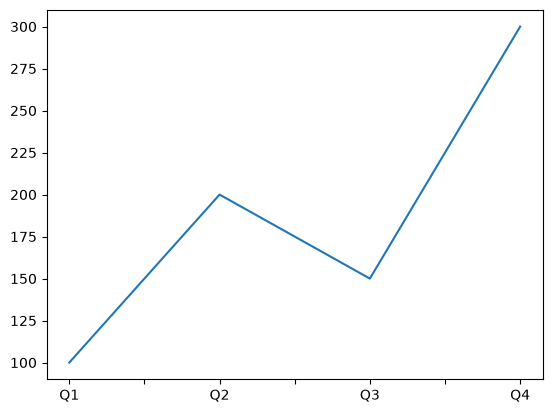

In [37]:
data.plot()

| Marker Symbol | Description |
| :---: | :---: |
| `'o'` | Circle |
| `'.'` | Point |
| `','` | Pixel |
| `'x'` | X |
| `'+'` | Plus |
| `'s'` | Square |
| `'D'` | Diamond |
| `'^'` | Upward Triangle |

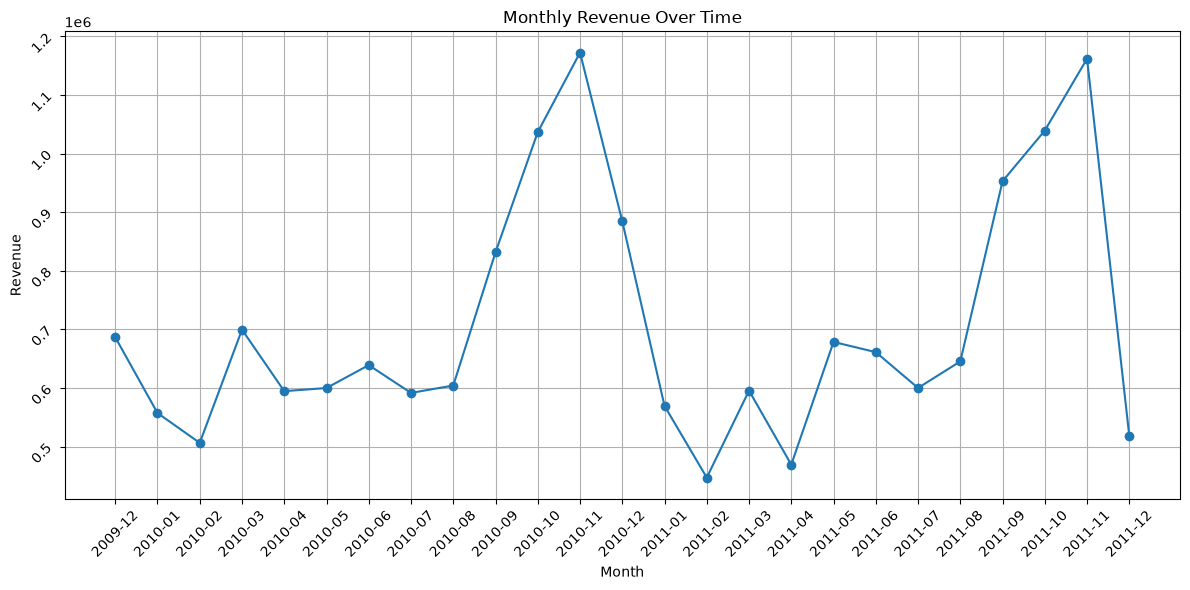

In [38]:
# Steps to create any plot using matplotlib.pyplot

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

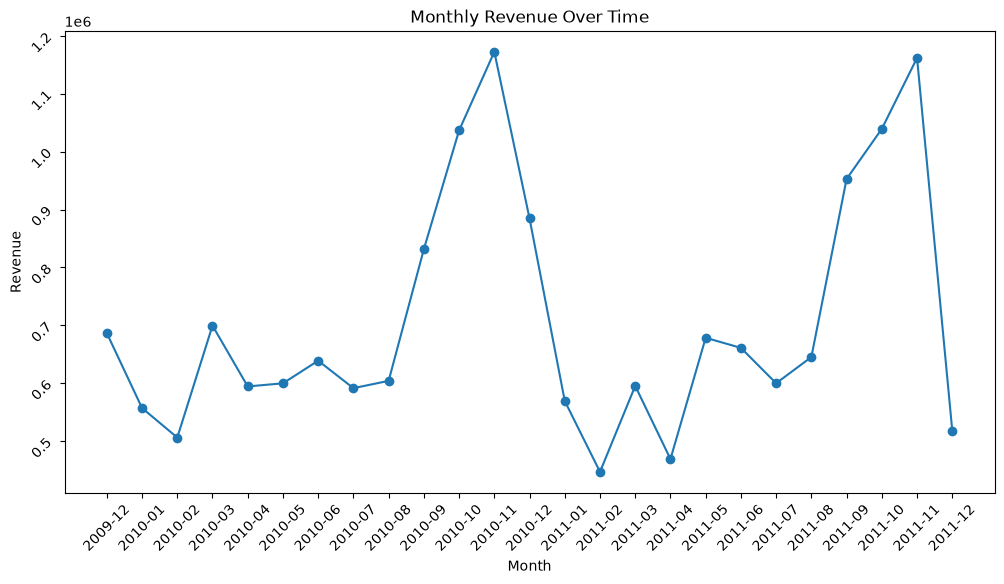

In [39]:
# without grid

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
# plt.tight_layout()

# Step-8: Show grid
# plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

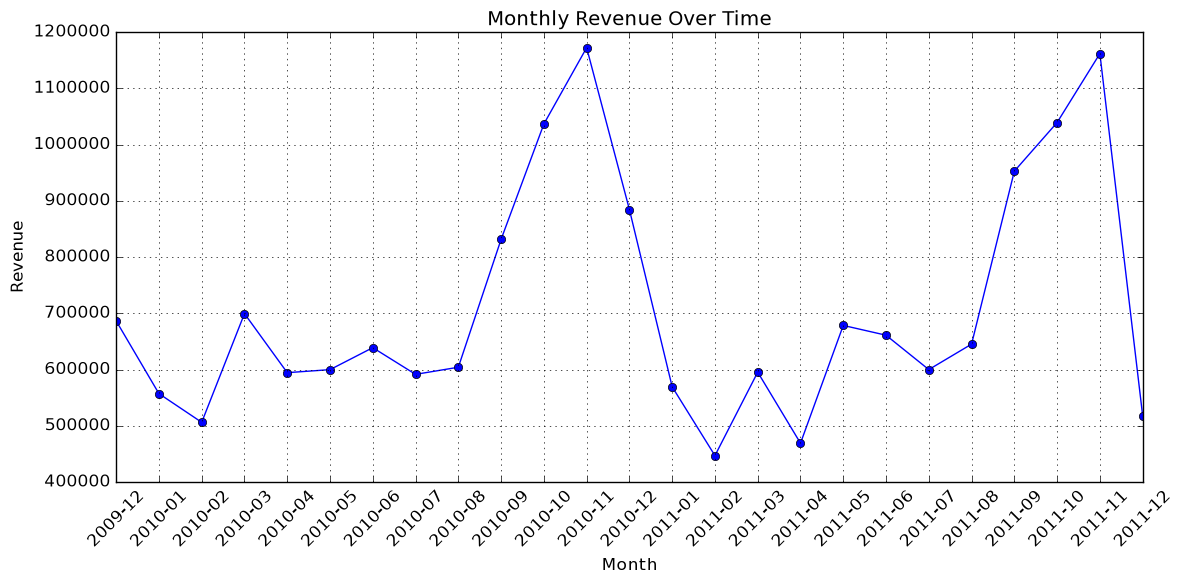

In [40]:
# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

In [41]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


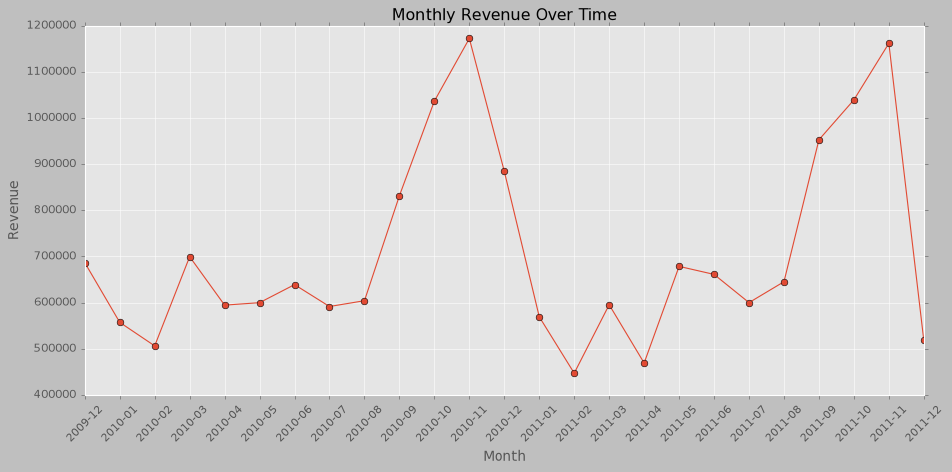

In [42]:
# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('ggplot')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

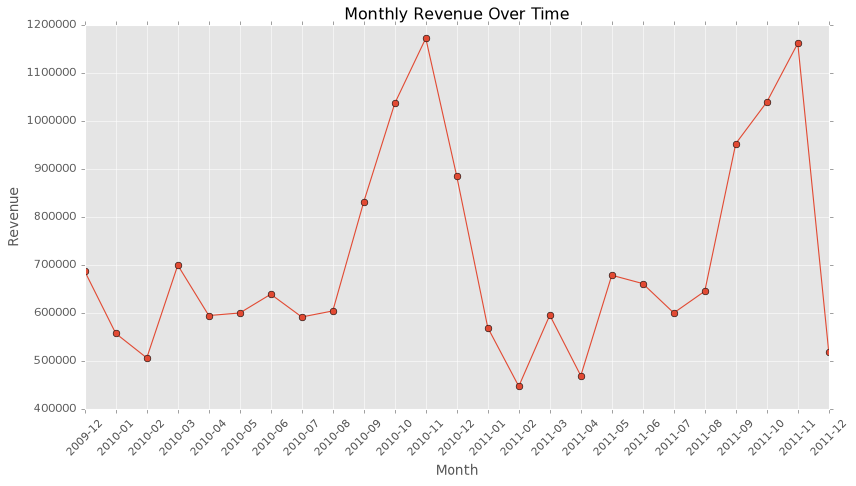

In [43]:
# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('ggplot')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
# plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

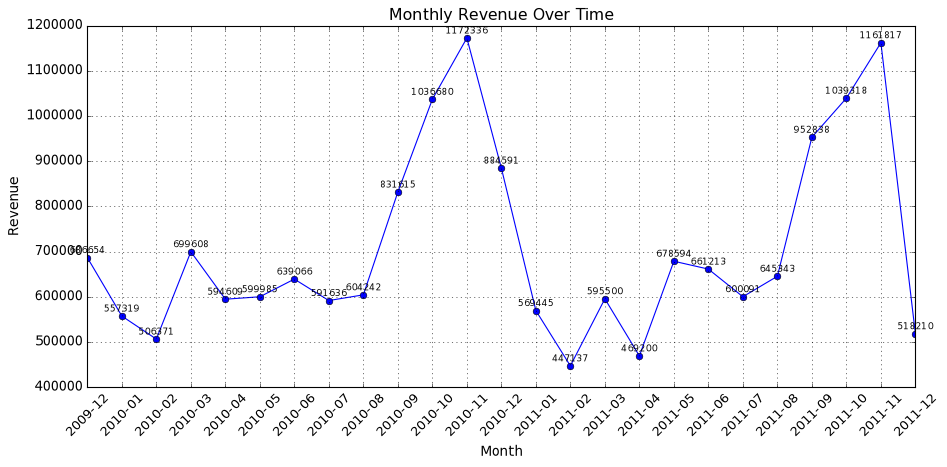

In [44]:
# adding labels on points

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value + 10000, f'{int(value)}', ha='center', fontsize=8)

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

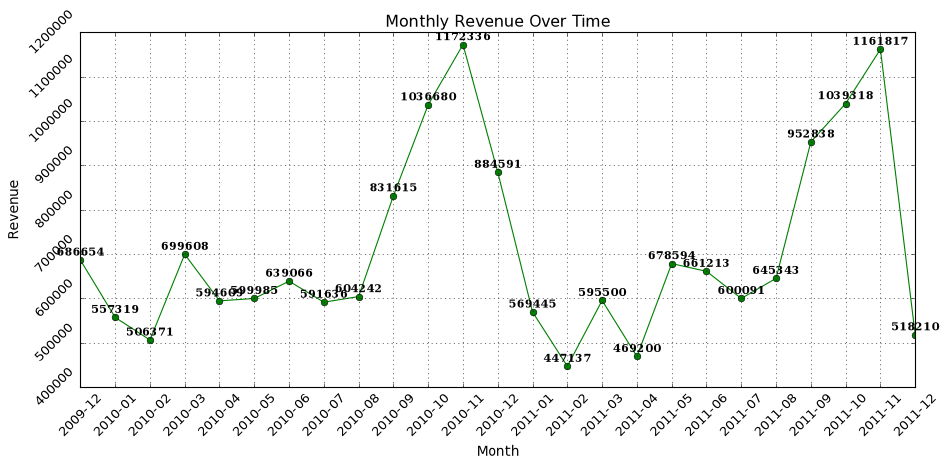

In [45]:
# adding labels on points
# using font-dict

font = {
    'family' : 'serif',
    'color' : 'black',
    'weight' : 'bold',
    'size' : 10
}

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6), facecolor='white')

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='green')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value + 10000, f'{int(value)}', ha='center', fontdict=font)

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

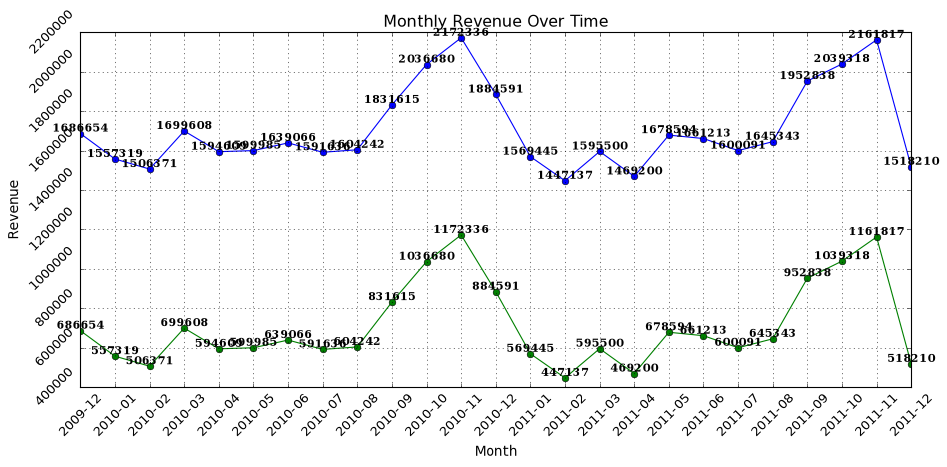

In [46]:
# plotting multiple graphs on the same plot
# adding labels on points
# using font-dict

font = {
    'family' : 'serif',
    'color' : 'black',
    'weight' : 'bold',
    'size' : 10
}

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6), facecolor='white')

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
# The first line plot
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='green')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value + 10000, f'{int(value)}', ha='center', fontdict=font)

# The second line plot
plt.plot(monthly_revenue.index, monthly_revenue.values+1000000, marker='o')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], (value+1000000) + 10000, f'{int(value+1000000)}', ha='center', fontdict=font)

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

### Bar Plot

In [47]:
# Objective: Show top 10 revenue-generating countries

In [48]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [49]:
country_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

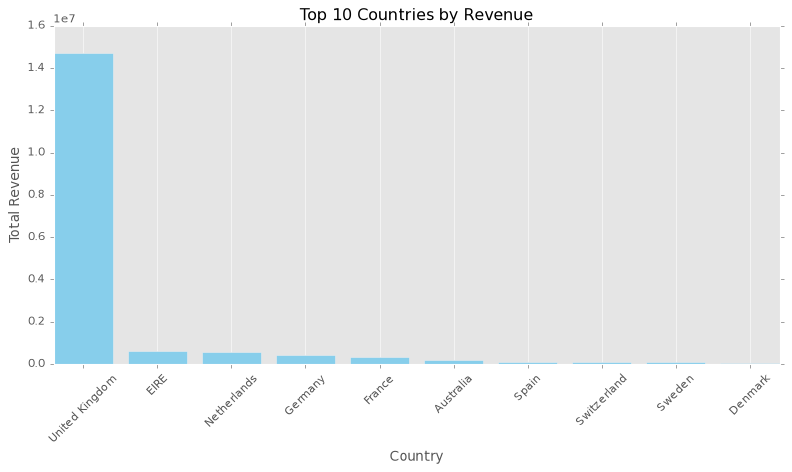

In [52]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.bar(country_revenue.index, country_revenue.values, color='skyblue')
plt.style.use('ggplot')

# Customizations
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')

plt.show()